In [1]:
# scientific libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from mpl_toolkits.axes_grid1.anchored_artists import AnchoredSizeBar
from skimage import io
from scipy.stats import circvar, circmean, circstd
import brokenaxes

# general libraries
import os  
import json
import time
import h5py as h5py
import copy
from pprint import pp, saferepr

# jupyter imports
import ipywidgets as widgets
from IPython.display import clear_output

# local libraries
from analysis import *
from general_utils import *
from hdf_utils import unpack_hdf, Workspace
from scalebars import *
import deconv
from hsluv_colormaps import angle_cmap

import sac_mode_configs as configs
# import experiments as exps
import analysis as ana
from interactive import MotionResponse
from line_data_units import LineDataUnits

In [2]:
%matplotlib widget
plt.rcParams.update({"figure.max_open_warning": 0, "mathtext.default": "regular"})
plt.rcParams['svg.fonttype'] = 'none'  # don't save font as paths (assumes font present on machine)

In [3]:
base_path = "/mnt/Data/NEURONoutput/sac_net/"
exts = [".png", ".svg"]

bmb_green = "#009800ff"
bmb_magenta = "#fe36d0ff"
# hsl for use with angle_cmap (https://htmlcolors.com/hex-to-hsl)
bmb_magenta_hsl = (314, 99, 60)
bmb_green_hsl = (120, 100, 30)

arrow_lbls = ["⬉", "⬆", "⬈", "➡", "⬊", "⬇", "⬋", "⬅"]
arrow_lbls = ["↖", "↑", "↗", "→", "↘", "↓", "↙", "←"]

In [4]:
model_path = os.path.join(base_path, "model_runs")
analysis_path = os.path.join(model_path, "analysis")
fig_path = os.path.join(base_path, "tree_analysis_figs")
fig_subdir = None

fig_subdir, exp_names = ("thesis_9n_3tr", {
    "spk": "thesis_6n_3tr_tree",
    "ttx": "thesis_ttx_6n_3tr_tree",
})

fig_path = fig_path if fig_subdir is None else os.path.join(fig_path, fig_subdir)
exp_hdfs = {k: h5.File(os.path.join(model_path, n) + ".h5", "r") for k, n in exp_names.items()}
d = {k: Workspace(hdf, read_only=True) for k, hdf in exp_hdfs.items()}
os.makedirs(fig_path, exist_ok=True)

exps = list(d.keys())
rhos = list(d["spk"].keys())
idxs = list(d["spk"][rhos[0]].keys())
n_trials, n_dirs, _ = d["spk"][rhos[0]][idxs[0]]["soma"]["Vm"][:].shape
print("==keys==")
print("rhos:", rhos)
print("idxs:", idxs)
print("exp keys:", list(d["spk"][rhos[0]][idxs[0]].keys()))

==keys==
rhos: [0.0, 1.0]
idxs: [0, 1, 2, 3, 4, 5]
exp keys: ['dendrites', 'metrics', 'params', 'sac_net', 'soma', 'syn_locs']


In [5]:
def close_button():
    button = widgets.Button(description="Close Workspace")
    out = widgets.Output()

    def on_clicked(_):
        with out:
            clear_output()
            for wrk in d.values():
                wrk.close()
            print("File closed!")
        
    button.on_click(on_clicked)
    return widgets.VBox([button, out])

close_button()

In [6]:
an = {}
for k, exp in exp_names.items():
    with h5.File(os.path.join(analysis_path, exp) + ".h5", "r") as hdf:
        an[k] = unpack_hdf(hdf)
    if "origins" in an[k]:  # not incl in ttx
        an[k]["origins"] = {
            rho: {
                net: [
                    [
                        an[k]["origins"][rho][net][tr][dr]
                        for dr in range(len(an[k]["origins"][rho][net][tr]))
                    ]
                    for tr in range(len(an[k]["origins"][rho][net]))
                ]
                for net in idxs
            }
            for rho in rhos
        }
        
tuning = an["ttx"]["tuning_vm"]
tuning = an["ttx"]["tuning_cai"]

origins = an["spk"]["origins"]
origins_sum = an["spk"]["origins_sum"]
path_sum = an["spk"]["path_sum"]
avg_path_sum = an["spk"]["avg_path_sum"]
net_avg_path_sum = an["spk"]["net_avg_path_sum"]

with h5.File("thesis_morphology.h5", "r") as f:
    morph = unpack_hdf(f)

print("morph keys:", list(morph.keys()))

morph keys: ['soma3d', 'soma2d', 'dend_diam', 'dend3d']


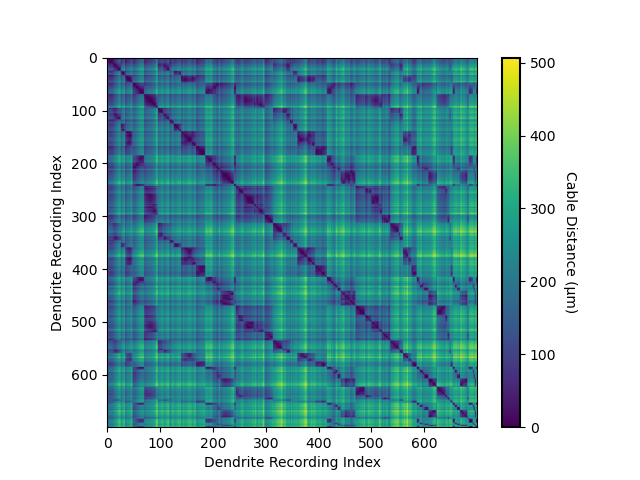

In [7]:
rec_locs = d["spk"][0.0][0]["dendrites"]["locs"][:]
syn_locs = d["spk"][0.0][0]["syn_locs"][:]
rec_dists = d["spk"][0.0][0]["dendrites"]["rec_dists"][:]
rec_dist_fig, rec_dist_ax = plt.subplots(1)
rec_dist_im = rec_dist_ax.imshow(rec_dists)
rec_dist_ax.set_xlabel("Dendrite Recording Index")
rec_dist_ax.set_ylabel("Dendrite Recording Index")
rec_dist_cbar = rec_dist_fig.colorbar(rec_dist_im)
rec_dist_cbar.set_label("Cable Distance (μm)", rotation=270, labelpad=15)
rec_dist_cbar.outline.set_linewidth(1.5)

In [8]:
params = d["spk"][1.0][0]["params"]
xaxis = np.arange(int(params["tstop"] / params["dt"]) + 1) * params["dt"]
metrics = {exp: ana.get_sac_metrics(wrk) for exp, wrk in d.items()}

dir_labels = d["spk"][rhos[0]][idxs[0]]["params"]["dir_labels"][:]
null_idx = np.argwhere(dir_labels == 180)[0][0]
pref_idx = np.argwhere(dir_labels == 0)[0][0]
sac_thetas = {exp: ana.get_sac_thetas(wrk) for exp, wrk in d.items()}
sac_deltas = {exp: ana.get_sac_deltas(ts) for exp, ts in sac_thetas.items()} 
syn_rec_lookups = get_syn_rec_lookups(rec_locs, syn_locs)

soma_vm = {
    exp: {
       rho: np.stack([d[exp][rho][net]["soma"]["Vm"] for net in idxs], axis=0)
       for rho in rhos
    } 
    for exp in exps
}

print("metrics:", list(metrics["spk"][rhos[0]].keys()))

metrics: ['spikes', 'thetas', 'DSis', 'avg_theta', 'avg_DSi']


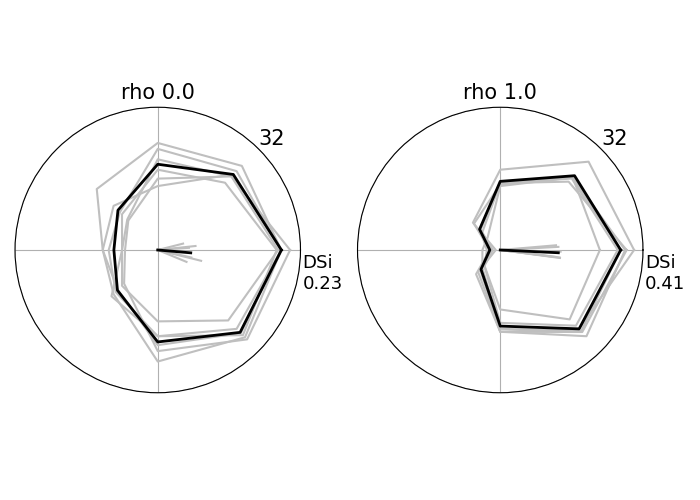

In [9]:
show_rhos = rhos
max_spikes = np.max([metrics["spk"][r]["spikes"] for r in show_rhos])
polar_fig = plt.figure(figsize=(7, 5))
n_cols = len(show_rhos)
polar_ax = [
    polar_plot(
        metrics["spk"][r],
        dir_labels,
        title="rho " + str(r),
        radius=max_spikes,
        net_shadows=True,
        save=False,
        fig=polar_fig,
        sub_loc=(1, n_cols, loc + 1),
        title_metrics=False,
    )
    for loc, r in enumerate(show_rhos)
]
polar_fig.tight_layout()

rho_lbl = str(show_rhos)[1:-1].replace(", ", "_").replace(".", "p")
for ext in [".png", ".svg"]:
    polar_fig.savefig(os.path.join(fig_path, "polar_%s%s" % (rho_lbl, ext)), bbox_inches="tight")

In [10]:
wonk_theta = 100
wonk_dsi = 0.1
wonk_dist = 10

wonk, culprit_sites, culprit_syns = ({rho: {} for rho in rhos} for _ in range(3))
for rho in rhos:
    for net in idxs:
        wonk[rho][net] =  np.where(
            (np.abs(tuning[rho][net]["avg"]["theta"]) > wonk_theta)
            * (tuning[rho][net]["avg"]["DSi"] > wonk_dsi)
        )[1]
        culprit_sites[rho][net] = np.unique(np.concatenate([
            np.where(rec_dists[w] < wonk_dist)[0] for w in wonk[rho][net]
        ])) if len(wonk[rho][net]) else []
        culprit_syns[rho][net] = np.sort(np.array([
            syn_rec_lookups["to_syn"][s] for s in culprit_sites[rho][net] if s in syn_rec_lookups["to_syn"]
        ], dtype=int))
        
print("wonky tuning sites (%s° wrong, DSI > %s):" % (str(wonk_theta), str(wonk_dsi)))
for rho in rhos:
    print("=== rho %s ===" % str(rho))
    for net in idxs:
        if len(wonk[rho][net]):
            print("  net %i: " % net, end="")
            pp(list(wonk[rho][net]), width=100, compact=True, indent=4)
        
print("\nexpanded culprit recording sites (within %sμm of wonky sites):" % wonk_dist)
for rho in rhos:
    print("=== rho %s ===" % str(rho))
    for net in idxs:
        if len(culprit_sites[rho][net]):
            print("  net %i: " % net, end="")
            pp(list(culprit_sites[rho][net]), width=100, compact=True, indent=4)

print("\nculprit synapses (colocated with culprit recording sites):")
for rho in rhos:
    print("=== rho %s ===" % str(rho))
    for net in idxs:
        if len(culprit_sites[rho][net]):
            print("  net %i: " % net, end="")
            pp(list(culprit_syns[rho][net]), width=100, compact=True, indent=4)


culprit_syn_locs = {r: {n: d["spk"][r][n]["syn_locs"][culprit_syns[r][n]] for n in idxs} for r in rhos}
culprit_bp_locs = {
    r: {
        n: {k: d["spk"][r][n]["sac_net"]["wiring"]["bp_locs"][k][culprit_syns[r][n]] for k in ["E", "I"]}
        for n in idxs
    }
    for r in rhos
}
culprit_bp_probs = {
    r: {
        n: {k: d["spk"][r][n]["sac_net"]["wiring"]["probs"][k][culprit_syns[r][n]] for k in ["E", "I"]}
        for n in idxs
    }
    for r in rhos
}

wonky tuning sites (100° wrong, DSI > 0.1):
=== rho 0.0 ===
  net 0: [0, 1, 434, 435, 592, 593, 594, 595, 658, 659, 660, 661, 692, 693]
  net 1: [   0, 1, 374, 375, 376, 377, 562, 563, 566, 567, 568, 569, 618, 619, 620, 621, 668, 669, 670, 671,
    688, 689, 690, 691, 694, 695, 698, 699]
  net 2: [374, 375, 376, 377, 566, 567, 568, 569]
  net 3: [   0, 1, 372, 373, 374, 375, 376, 377, 566, 567, 568, 569, 614, 615, 616, 617, 618, 619, 620, 621,
    656, 657, 668, 669, 670, 671, 672, 673, 674, 675, 676, 677, 684, 685, 686, 687, 688, 689, 690,
    691, 696, 697, 698, 699]
  net 4: [0, 1, 376, 377, 568, 569, 594, 595, 658, 659, 660, 661, 688, 689, 690, 691, 692, 693, 698, 699]
  net 5: [0, 1, 686, 687, 688, 689, 690, 691, 698, 699]
=== rho 1.0 ===
  net 0: [374, 375, 376, 377, 568, 569]
  net 1: [568, 569]
  net 2: [376, 377, 568, 569]
  net 5: [568, 569, 620, 621, 670, 671]

expanded culprit recording sites (within 10μm of wonky sites):
=== rho 0.0 ===
  net 0: [0, 1, 433, 434, 435, 592, 

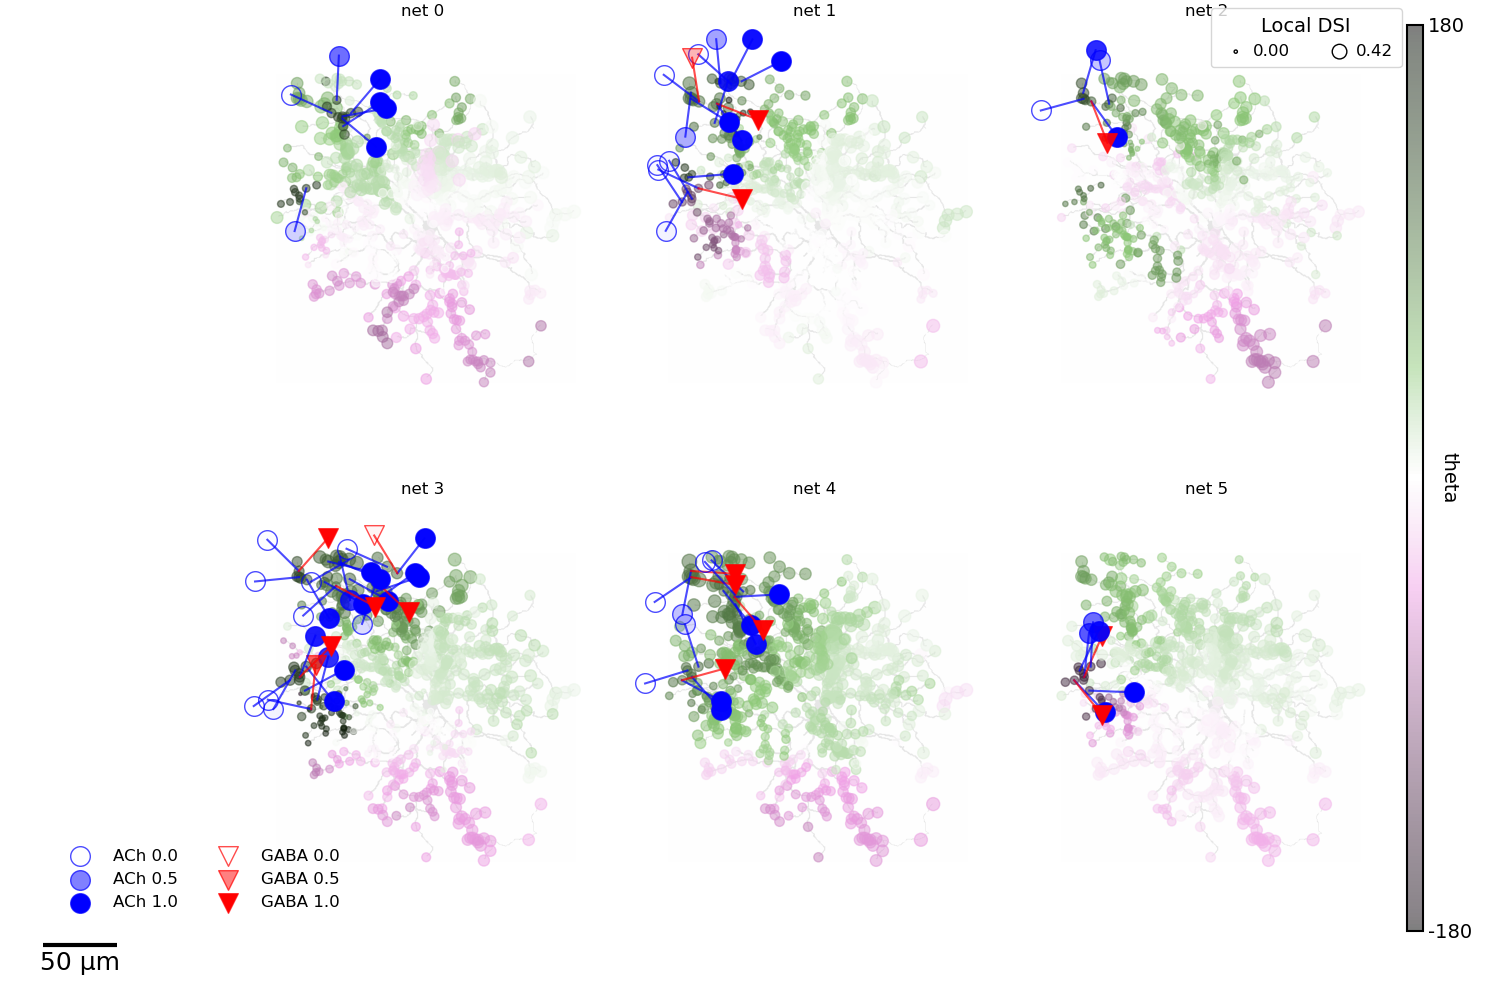

In [11]:
rho = 0.0
show_nets = idxs
# show_nets = [0]

show_tuning = True
show_dsgc = True
show_sacs = True
dsgc_alpha = 0.1
net_titles = True

stim_angle = 180
gamma = 0.01
min_size = None
csteps = 512
c_clear = mpl.colors.colorConverter.to_rgba("white", alpha = 0)
c_black = mpl.colors.colorConverter.to_rgba("black", alpha = 1)
c_red = mpl.colors.colorConverter.to_rgba("red", alpha = 1)
c_blue = mpl.colors.colorConverter.to_rgba("blue", alpha = 1)
cmap = mpl.colors.LinearSegmentedColormap.from_list("rb_cmap", [c_clear, c_black], csteps, gamma=gamma)
ach_cmap = mpl.colors.LinearSegmentedColormap.from_list("rb_cmap", [c_clear, c_blue], csteps, gamma=gamma)
gaba_cmap = mpl.colors.LinearSegmentedColormap.from_list("rb_cmap", [c_clear, c_red], csteps, gamma=gamma)

max_cols = 3
col_width = 5
cbar_frac = 0.04

if not show_tuning and not show_dsgc and not show_sacs:
    raise ValueError("Nothing to see here...")

nrows = max(1, len(show_nets) // max_cols)
ncols = min(len(show_nets), max_cols)
base_frac = 1 / ncols
slice_frac = cbar_frac * base_frac / ncols
row_height = col_width
tuning_culprit_fig = plt.figure(figsize=(col_width * ncols, row_height * nrows))
gs = tuning_culprit_fig.add_gridspec(
    nrows=nrows,
    ncols=ncols+1,
    width_ratios=[base_frac - slice_frac] * ncols + [slice_frac * ncols],
)
if show_dsgc:
    dsgc_img, extent = get_dsgc_img()

dsi_min = np.min([np.min(tuning[rho][n]["avg"]["DSi"]) for n in show_nets])
dsi_max = np.max([np.max(tuning[rho][n]["avg"]["DSi"]) for n in show_nets])

for i, n in enumerate(show_nets):
    col = i % ncols
    row = i // ncols
    ax = tuning_culprit_fig.add_subplot(gs[row, col])
    ax.set_aspect("equal")
    ax.set_xlim(-30, 230)
    ax.set_ylim(-10, 250)
    clean_axes(ax, remove_spines=["top", "left", "bottom", "right"])
    if net_titles: ax.set_title("net %i" % n)
    if show_dsgc:
        ax.imshow(dsgc_img, extent=extent, alpha=dsgc_alpha, cmap="gray")
    if not i:
        # add colorbar even without show_tuning so that it can be removed
        cax = tuning_culprit_fig.add_subplot(gs[:, -1])
        clean_axes(cax, remove_spines=["top", "left", "bottom", "right"])
    if show_tuning:
        if not i:
            cax = tuning_culprit_fig.add_subplot(gs[:, -1])
        tuning_scatter, tuning_cbar = tree_tuning(
            tuning_culprit_fig,
            ax,
            rec_locs,
            tuning[rho][n]["avg"]["theta"],
            tuning[rho][n]["avg"]["DSi"],
            abstheta=False,
            theta_min=-180,
            theta_max=180,
            dsi_mul=250,
            dsi_min=dsi_min,
            dsi_max=dsi_max,
            min_dsi_size=5,
            # cmap=angle_cmap(use_hpl=True),
            cmap=angle_cmap(pos_hue=bmb_magenta_hsl[0], neg_hue=bmb_green_hsl[0], use_hpl=True),
            cbar=(not i),
            cbar_kwargs={"cax": cax},
            # legend_kwargs={"loc": "upper right"},
            legend=None if i else "fig",
            legend_kwargs={
                "loc": "upper right", "bbox_to_anchor": (0.84, 0.9, 0.1, 0.1), "frameon": True,
                "borderpad": 0.5, "handletextpad": 0, "title": "Local DSI", "title_fontsize": 14,
            },
        )
    else:
        cax.remove()
        
    if show_sacs:
        ana.plot_dends_overlay(
            tuning_culprit_fig,
            ax,
            culprit_syn_locs[rho][n],
            culprit_bp_locs[rho][n],
            culprit_bp_probs[rho][n],
            dir_labels,
            stim_angle=stim_angle,
            dsgc_alpha=0.0,
            sac_thickness=1.5,
            sac_marker_size=200,
            sac_min_marker_size=min_size,
            ach_color="blue",
            gaba_color="red",
            ach_edge="blue",
            gaba_edge="red",
            cmap=cmap,
            ach_cmap=ach_cmap,
            gaba_cmap=gaba_cmap,
            incl_cbars=False,
            legend=col == 0 and row == (nrows - 1),
            scaling_legend=True,
        )
            
    if col == 0 and row == (nrows - 1):
        tree_sizex = 50
        add_scalebar(
            ax,
            matchx=False, 
            matchy=False, 
            sizex=tree_sizex, 
            labelx="%i μm" % tree_sizex,
            sep=5,
            barwidth=3,
            loc="center",
            bbox_to_anchor=(80, 40),
            textprops={"fontsize": 18},
            hidey=False,
        )
        
    if show_tuning and not i:
        ticks = [int(tuning_cbar.vmin), int(tuning_cbar.vmax)]
        tuning_cbar.set_ticks(ticks, labels=ticks, size=14)
        tuning_cbar.set_label("theta", rotation=270, labelpad=-10, fontsize=14)
        cax.tick_params(width=0, size=0)
        tuning_cbar.outline.set_linewidth(1.5)

tuning_culprit_fig.set_layout_engine("compressed")

tuning_lbl = "tuning_" if show_tuning else ""
sacs_lbl = "culprits_"
dsgc_lbl = "over_dsgc_" if show_dsgc else ""
nets_lbl = "all_nets" if len(show_nets) == len(idxs) else "net%s%s" % (
    "s" if len(show_nets) > 1 else "", "_".join(map(str, show_nets)))
name = os.path.join(fig_path, "%s%s%srho%s_net%i_wonk_%s°_dsi%s_dist%s" % (
        tuning_lbl, sacs_lbl, dsgc_lbl, str(rho), net, str(wonk_theta), str(wonk_dsi), str(wonk_dist)))
for ext in exts:
    tuning_culprit_fig.savefig(name + ext, bbox_inches="tight")

In [12]:
# TODO: for the spike paths, I think that revealing the SAC inputs around the origin sites would be interesting.
# presumably, there will be ACh inputs that prefer the stimulus direction nearby

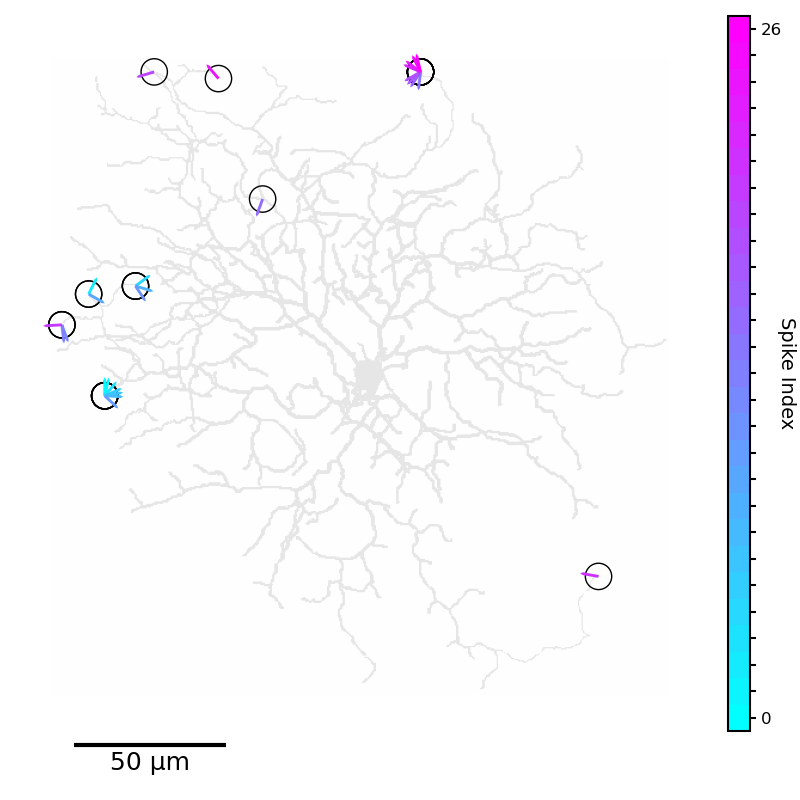

In [13]:
rho = 0.0
net = 3  
trial = 2
i = 4 
origs = origins[rho][net][trial][i]

arrow_sz = 180
spk_ownership = {r: [] for r in origs}
ring_lvl = []
origs_mass = np.zeros(2)
for i, org in enumerate(origs):
    ring_lvl.append(len(spk_ownership[org]))
    spk_ownership[org].append(i)
    origs_mass += rec_locs[org]
origs_mass /= len(origs)

ring_base = 10
ring_step = 40
ring_lw = 2
cmap = plt.get_cmap("cool", lut=len(origs))

spk_origins_fig, spk_origins_ax = plt.subplots(
    1, 2, figsize=(8, 8), gridspec_kw={"width_ratios": [0.97, 0.03]})
dsgc_img, dsgc_extent = get_dsgc_img()
spk_origins_ax[0].imshow(dsgc_img, extent=dsgc_extent, alpha=dsgc_alpha, cmap="gray")
rads = np.arange(len(origs)) * -np.pi * 2 / len(origs) + (np.pi / 2)  # 0 at 12oclock, clockwise
u = np.cos(rads) * np.sqrt(arrow_sz) / 72  # scaling into points to match markersize units
v = np.sin(rads) * np.sqrt(arrow_sz) / 72
xy = np.stack([rec_locs[org] for org in origs], axis=1)
c = np.arange(len(origs)) / (len(origs) - 1)
spk_origins_ax[0].scatter(xy[0], xy[1], s=arrow_sz * 2, facecolors="none", edgecolors="black")
spk_origins_ax[0].quiver(
    xy[0], xy[1], u, v, c, angles='xy', scale_units='inches', scale=1, width=0.004, headwidth=1, headlength=1, cmap=cmap)

cbar_lw = 1.5
origins_cbar = spk_origins_fig.colorbar(
    plt.cm.ScalarMappable(cmap=cmap),
    orientation="vertical",
    cax=spk_origins_ax[1],
    values=np.arange(len(origs)),
    ticks=np.arange(len(origs)),
)
origins_cbar.set_label("Spike Index", rotation=270, labelpad=10, fontsize=14)
spk_origins_ax[-1].tick_params(width=cbar_lw, size=4)
origins_cbar.outline.set_linewidth(cbar_lw)
spk_origins_ax[1].set_yticklabels(
    [0] + [None for _ in range(len(origs) - 2)] + [len(origs) - 1], fontsize=12)
spk_origins_ax[0].set_aspect("equal")
spk_origins_ax[0].set_xlim(-15, 220)
spk_origins_ax[0].set_ylim(5, 240)

tree_sizex = 50
add_scalebar(
    spk_origins_ax[0],
    matchx=False, 
    matchy=False, 
    sizex=tree_sizex, 
    labelx="%i μm" % tree_sizex,
    sep=5,
    barwidth=3,
    loc="center",
    bbox_to_anchor=(150, 40),
    textprops={"fontsize": 18},
)

spk_origins_fig.set_layout_engine("compressed")

name = os.path.join(fig_path, "spike_origins_rho%s_net%i_trial%i" % (("%.2f" % rho).replace(".", "p"), net, trial))
for ext in exts:
    spk_origins_fig.savefig(name + ext, bbox_inches="tight")

In [14]:
spkr_thresh = 1
spkr_dist = 30

spkr_sites, spkr_sites_dirs, spkr_syns, spkr_syns_dirs = ({rho: {} for rho in rhos} for _ in range(4))
for rho in rhos:
    for net in idxs:
        spkr_sites[rho][net] = [
            [
                    np.unique(np.concatenate([
                    np.where(rec_dists[w] < spkr_dist)[0]
                        for w in np.where(origins_sum[rho][net, tr, dr] >= spkr_thresh)[0]
                ])) if np.sum(origins_sum[rho][net, tr, dr]) else []
                for dr in range(n_dirs)
            ]
            for tr in range(n_trials)
        ]
        spkr_sites_dirs[rho][net] = [
            np.unique(np.concatenate([spkr_sites[rho][net][tr][dr] for tr in range(n_trials)]))
            for dr in range(n_dirs)
        ]
        spkr_syns[rho][net] = [
            [
                np.sort(np.array([
                    syn_rec_lookups["to_syn"][s] for s in spkr_sites[rho][net][tr][dr]
                    if s in syn_rec_lookups["to_syn"]
                ], dtype=int))
                for dr in range(n_dirs)
            ]
            for tr in range(n_trials)
        ]
        spkr_syns_dirs[rho][net] = [
            np.sort(np.array([
                syn_rec_lookups["to_syn"][s] for s in spkr_sites_dirs[rho][net][dr]
                if s in syn_rec_lookups["to_syn"]
            ], dtype=int))
            for dr in range(n_dirs)
        ]


spkr_syn_locs = {r: {n: [[d["spk"][r][n]["syn_locs"][spkr_syns[r][n][tr][dr]] for dr in range(n_dirs)] 
                         for tr in range(n_trials)]
                     for n in idxs} for r in rhos}
spkr_bp_locs = {
    r: {
        n: [[{k: d["spk"][r][n]["sac_net"]["wiring"]["bp_locs"][k][spkr_syns[r][n][tr][dr]]
              for k in ["E", "I"]}
             for dr in range(n_dirs)] for tr in range(n_trials)] 
        for n in idxs
    }
    for r in rhos
}
spkr_bp_probs = {
    r: {
        n: [[{k: d["spk"][r][n]["sac_net"]["wiring"]["probs"][k][spkr_syns[r][n][tr][dr]]
              for k in ["E", "I"]}
             for dr in range(n_dirs)] for tr in range(n_trials)] 
        for n in idxs
    }
    for r in rhos
}
spkr_syn_locs_dirs = {r: {n: [d["spk"][r][n]["syn_locs"][spkr_syns_dirs[r][n][dr]] for dr in range(n_dirs)]
                     for n in idxs} for r in rhos}
spkr_bp_locs_dirs = {
    r: {
        n: [{k: d["spk"][r][n]["sac_net"]["wiring"]["bp_locs"][k][spkr_syns_dirs[r][n][dr]]
              for k in ["E", "I"]}
             for dr in range(n_dirs)] 
        for n in idxs
    }
    for r in rhos
}
spkr_bp_probs_dirs = {
    r: {
        n: [{k: d["spk"][r][n]["sac_net"]["wiring"]["probs"][k][spkr_syns_dirs[r][n][dr]]
              for k in ["E", "I"]}
             for dr in range(n_dirs)] 
        for n in idxs
    }
    for r in rhos
}

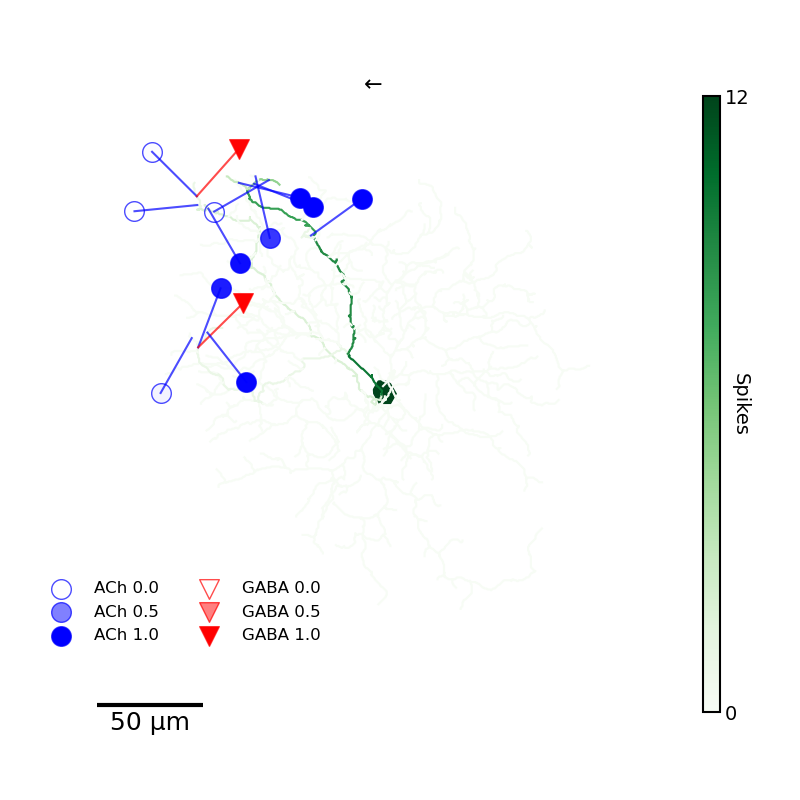

In [38]:
rho = 0.0
net = 3  
# net = None
trial = 2
# trial = None
i = 7

show_arrow = True
show_sacs = True
diam_mode = "fixed"  # "lw" | "3d" | "model" | "fixed"
dend_lw = 1.0        # used for "lw" diam_mode (regular ax.plot, axis units)
fixed_diam = 1.0     # used for "fixed" diam_mode (data unit lw)
alpha =  1
cmap = plt.get_cmap("cool")
cmap = plt.get_cmap("Blues")
cmap = plt.get_cmap("PuRd")
cmap = plt.get_cmap("Reds")
cmap = plt.get_cmap("Greens")
bgc = None

path_val = net_avg_path_sum[rho] if net is None else (
    avg_path_sum[rho][net] if trial is None else path_sum[rho][net, trial, :])
spk_vmax = path_val[i, 0]
dsgc_paths_fig, dsgc_paths_ax = plt.subplots(
    1, 2, figsize=(8, 8), gridspec_kw={"width_ratios": [0.97, 0.03]})

c = cmap(path_val[i, 0] / spk_vmax)
dsgc_paths_ax[0].fill(morph["soma2d"][:, 0], morph["soma2d"][:, 1], c=c, alpha=alpha)
dend_lines = []
for n in range(len(morph["dend3d"])):
    pts = morph["dend3d"][n]
    c = cmap(path_val[i, n + 1] / spk_vmax)
    if diam_mode == "lw":
        dsgc_paths_ax[0].plot(pts[:, 0], pts[:, 1], lw=dend_lw, c=c, alpha=alpha)
    else:
        lw = fixed_diam if diam_mode == "fixed" else (pts[0, 3] if diam_mode == "3d" else morph["dend_diam"][n])
        dend_lines.append(LineDataUnits(pts[:, 0], pts[:, 1], c=c, alpha=alpha, linewidth=lw))
        dsgc_paths_ax[0].add_line(dend_lines[-1])

dsgc_paths_ax[0].set_xlim(0, 210)
dsgc_paths_ax[0].set_ylim(10, 225)
dsgc_paths_ax[0].set_aspect("equal")

dsgc_paths_cbar = dsgc_paths_fig.colorbar(
    plt.cm.ScalarMappable(norm=plt.Normalize(vmin=0, vmax=spk_vmax), cmap=cmap),
    orientation="vertical",
    cax=dsgc_paths_ax[1],
)
ticks = [int(dsgc_paths_cbar.vmin), int(dsgc_paths_cbar.vmax)]
dsgc_paths_cbar.set_ticks(ticks, labels=ticks, size=14)
dsgc_paths_cbar.set_label("Spikes", rotation=270, labelpad=0, fontsize=14)
dsgc_paths_ax[-1].tick_params(width=0, size=0)
dsgc_paths_cbar.outline.set_linewidth(1.5)

if show_sacs:
    ana.plot_dends_overlay(
        dsgc_paths_fig,
        dsgc_paths_ax[0],
        spkr_syn_locs_dirs[rho][net][i] if trial is None else spkr_syn_locs[rho][net][trial][i],
        spkr_bp_locs_dirs[rho][net][i] if trial is None else spkr_bp_locs[rho][net][trial][i],
        spkr_bp_probs_dirs[rho][net][i] if trial is None else spkr_bp_probs[rho][net][trial][i],
        dir_labels,
        stim_angle=dir_labels[i],
        dsgc_alpha=0.0,
        sac_thickness=1.5,
        sac_marker_size=200,
        sac_min_marker_size=None,
        ach_color="blue",
        gaba_color="red",
        ach_edge="blue",
        gaba_edge="red",
        cmap=cmap,
        ach_cmap=ach_cmap,
        gaba_cmap=gaba_cmap,
        incl_cbars=False,
        legend=True,
        scaling_legend=True,
        base_zorder=400,
        legend_kwargs={"loc": "upper right", "bbox_to_anchor": (0.45, 0.25)},
    )
    
tree_sizex = 50
add_scalebar(
    dsgc_paths_ax[0],
    matchx=False, 
    matchy=False, 
    sizex=tree_sizex, 
    labelx="%i μm" % tree_sizex,
    sep=5,
    barwidth=3,
    loc="center",
    bbox_to_anchor=(150, 80),
    textprops={"fontsize": 18},
)
if show_arrow: dsgc_paths_ax[0].set_title(arrow_lbls[i], fontsize=16)

net_lbl = "AVG" if net is None else str(net)
trial_lbl = "AVG" if trial is None else str(trial)
name = os.path.join(
    fig_path, "dsgc_spike_paths_rho%s_net%s_trial%s" % (("%.2f" % rho).replace(".", "p"), net_lbl, trial_lbl))
for ext in exts:
    dsgc_paths_fig.savefig(name + ext, bbox_inches="tight")

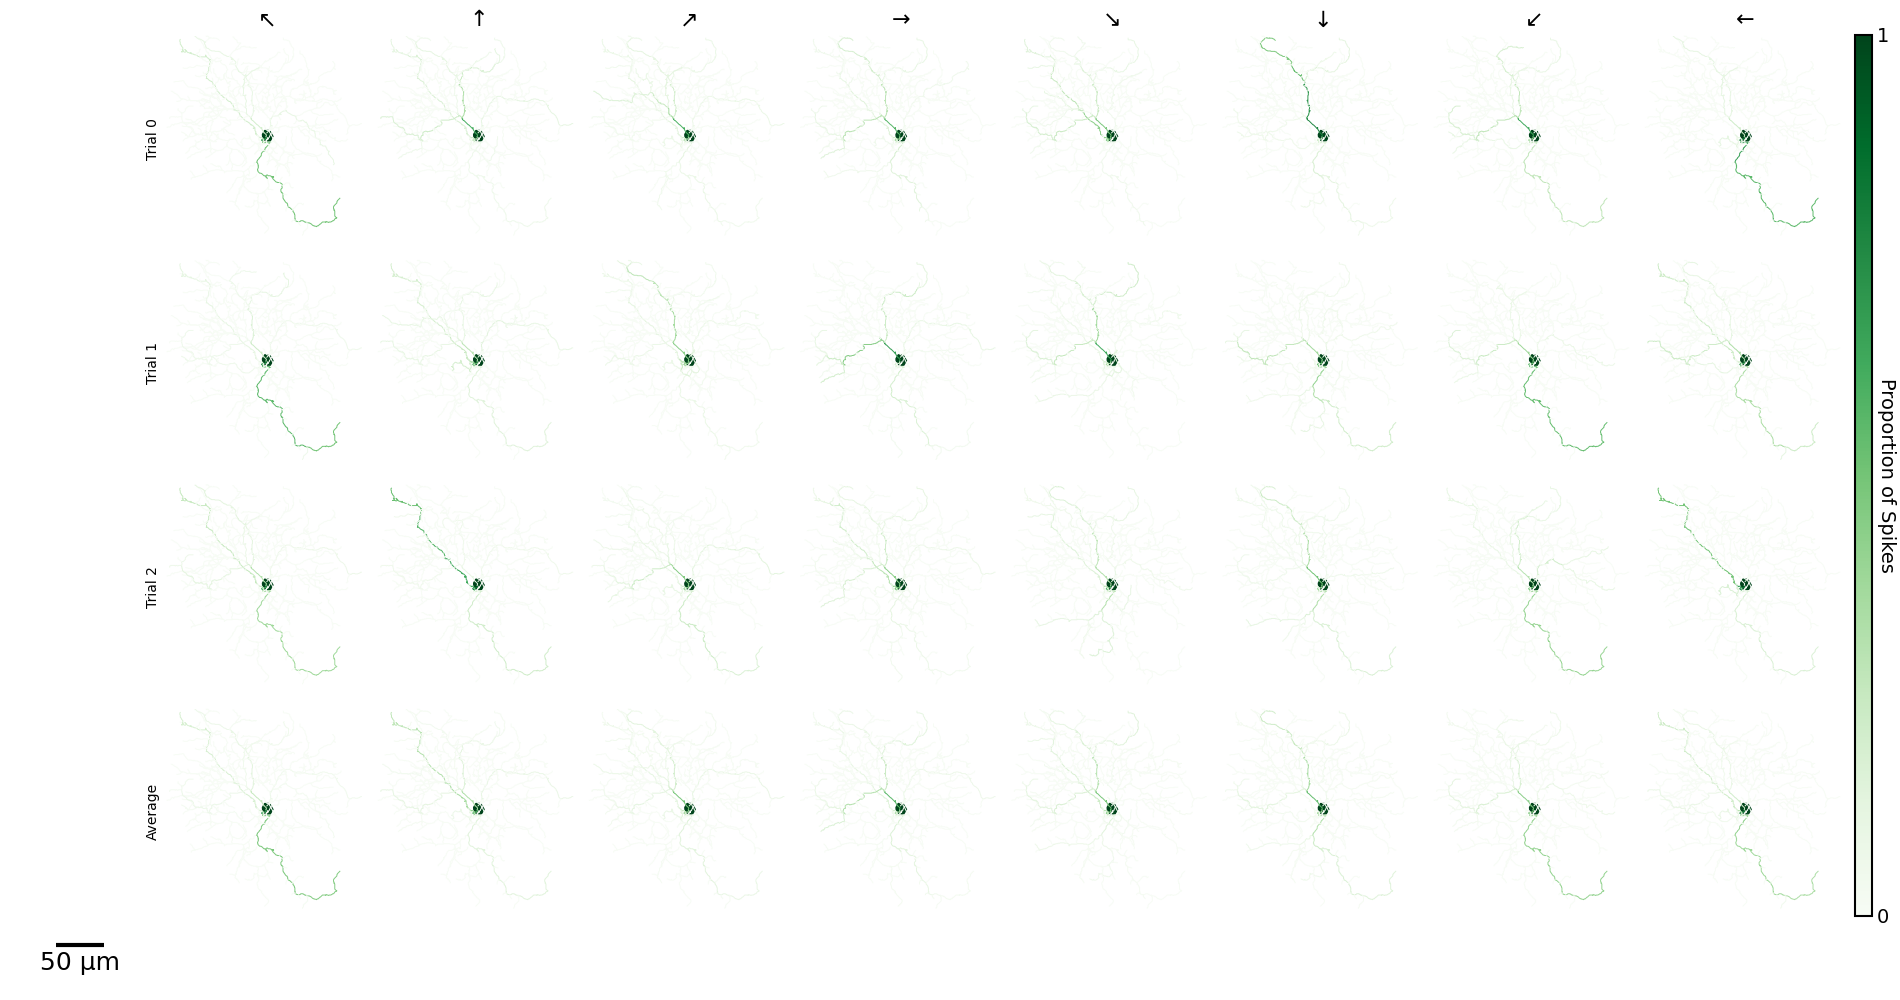

In [16]:
rho = 0.0
net = 2  
trials = np.arange(n_trials)
# trials = [0]
# trials = []
incl_avg = True or not len(trials) 

label_singles = False
no_labels = False

diam_mode = "fixed"  # "lw" | "3d" | "model" | "fixed"
dend_lw = 1.0        # used for "lw" diam_mode (regular ax.plot, axis units)
fixed_diam = 1.0     # used for "fixed" diam_mode (data unit lw)
alpha =  1
cmap = plt.get_cmap("cool")
cmap = plt.get_cmap("Blues")
cmap = plt.get_cmap("PuRd")
cmap = plt.get_cmap("Reds")
cmap = plt.get_cmap("Greens")
bgc = None

row_height = 10 / 4
nrows = len(trials) + int(incl_avg)
dsgc_paths_grid_fig = plt.figure(figsize=(19, row_height * nrows))
gs = dsgc_paths_grid_fig.add_gridspec(
    nrows=nrows,
    ncols=n_dirs+1,
    width_ratios=[0.99 / n_dirs] * n_dirs + [0.01],
)
for tr in range(len(trials) + int(incl_avg)):
    path_val = avg_path_sum[rho][net] if tr == len(trials) else path_sum[rho][net, trials[tr], :]
    for i in range(n_dirs):
        spk_vmax = path_val[i, 0]
        c = cmap(path_val[i, 0] / spk_vmax if spk_vmax else 0)
        ax = dsgc_paths_grid_fig.add_subplot(gs[tr, i])
        ax.fill(morph["soma2d"][:, 0], morph["soma2d"][:, 1], c=c, alpha=alpha)
        ax.set_xlim(0, 210)
        ax.set_ylim(10, 225)
        ax.set_aspect("equal")
        clean_axes(ax, remove_spines=["top", "left", "bottom", "right"])
        for n in range(len(morph["dend3d"])):
            pts = morph["dend3d"][n]
            c = cmap(path_val[i, n + 1] / spk_vmax if spk_vmax else 0)
            if diam_mode == "lw":
                ax.plot(pts[:, 0], pts[:, 1], lw=dend_lw, c=c, alpha=alpha)
            else:
                lw = fixed_diam if diam_mode == "fixed" else (pts[0, 3] if diam_mode == "3d" else morph["dend_diam"][n])
                ax.add_line(LineDataUnits(pts[:, 0], pts[:, 1], c=c, alpha=alpha, linewidth=lw))
        if i == 0:
            if tr == len(trials):
                tree_sizex = 50
                add_scalebar(
                    ax,
                    matchx=False, 
                    matchy=False, 
                    sizex=tree_sizex, 
                    labelx="%i μm" % tree_sizex,
                    sep=5,
                    barwidth=3,
                    loc="center",
                    bbox_to_anchor=(80, 40),
                    textprops={"fontsize": 18},
                    hidey=False,
                )
            if (nrows > 1 or label_singles) and not no_labels:
                ax.set_ylabel(("Trial %i" % trials[tr]) if tr < len(trials) else "Average")
        if tr == 0:
            ax.set_title(arrow_lbls[i], fontsize=16)


dsgc_paths_grid_fig.set_layout_engine("compressed")

dsgc_paths_grid_cbar_ax = dsgc_paths_grid_fig.add_subplot(gs[:, -1])
dsgc_paths_grid_cbar = dsgc_paths_grid_fig.colorbar(
    plt.cm.ScalarMappable(norm=plt.Normalize(vmin=0, vmax=1), cmap=cmap),
    orientation="vertical",
    cax=dsgc_paths_grid_cbar_ax,
)
ticks = [int(dsgc_paths_grid_cbar.vmin), int(dsgc_paths_grid_cbar.vmax)]
dsgc_paths_grid_cbar.set_ticks(ticks, labels=ticks, size=14)
dsgc_paths_grid_cbar.set_label("Proportion of Spikes", rotation=270, labelpad=5, fontsize=14)
dsgc_paths_grid_cbar_ax.tick_params(width=0, size=0)
dsgc_paths_grid_cbar.outline.set_linewidth(1.5)

trial_lbl = "_trials%s" % "-".join(map(str, trials)) if 0 < len(trials) < n_trials else ""
avg_lbl = "_only_avg" if not len(trials) else "_with_avg" if incl_avg else "" 
name = os.path.join(
    fig_path, "dsgc_spike_paths_grid_rho%s_net%i%s%s" % (("%.2f" % rho).replace(".", "p"), net, trial_lbl, avg_lbl))
for ext in exts:
    dsgc_paths_grid_fig.savefig(name + ext, bbox_inches="tight")

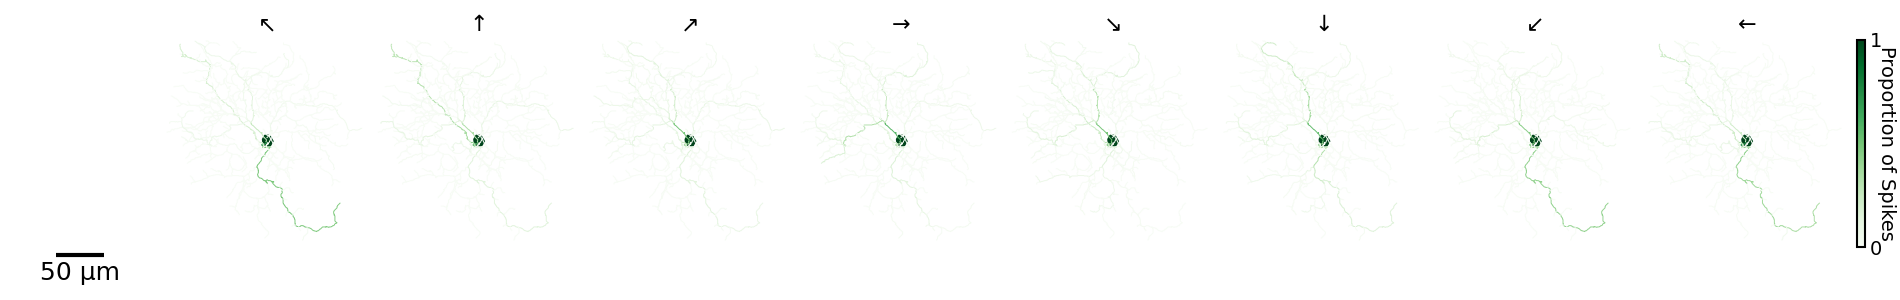

In [17]:
rho = 0.0

diam_mode = "fixed"  # "lw" | "3d" | "model" | "fixed"
dend_lw = 1.0        # used for "lw" diam_mode (regular ax.plot, axis units)
fixed_diam = 1.0     # used for "fixed" diam_mode (data unit lw)
alpha =  1
cmap = plt.get_cmap("cool")
cmap = plt.get_cmap("Blues")
cmap = plt.get_cmap("PuRd")
cmap = plt.get_cmap("Reds")
cmap = plt.get_cmap("Greens")
bgc = None

dsgc_paths_net_avg_fig, dsgc_paths_net_avg_ax = plt.subplots(
    1,
    n_dirs + 1,
    figsize=(19, 3),
    gridspec_kw={"width_ratios": [0.995 / n_dirs] * n_dirs + [0.005]}
)
net_avg_path_sum = avg_path_sum[rho][net] if tr == n_trials else path_sum[rho][net, tr, :]
for i in range(n_dirs):
    spk_vmax = net_avg_path_sum[i, 0]
    c = cmap(net_avg_path_sum[i, 0] / spk_vmax if spk_vmax else 0)
    ax = dsgc_paths_net_avg_ax[i]
    ax.fill(morph["soma2d"][:, 0], morph["soma2d"][:, 1], c=c, alpha=alpha)
    ax.set_xlim(0, 210)
    ax.set_ylim(10, 225)
    ax.set_aspect("equal")
    clean_axes(ax, remove_spines=["top", "left", "bottom", "right"])
    ax.set_title(arrow_lbls[i], fontsize=16)
    for n in range(len(morph["dend3d"])):
        pts = morph["dend3d"][n]
        c = cmap(net_avg_path_sum[i, n + 1] / spk_vmax)
        if diam_mode == "lw":
            ax.plot(pts[:, 0], pts[:, 1], lw=dend_lw, c=c, alpha=alpha)
        else:
            lw = fixed_diam if diam_mode == "fixed" else (pts[0, 3] if diam_mode == "3d" else morph["dend_diam"][n])
            ax.add_line(LineDataUnits(pts[:, 0], pts[:, 1], c=c, alpha=alpha, linewidth=lw))

dsgc_paths_net_avg_cbar = dsgc_paths_net_avg_fig.colorbar(
    plt.cm.ScalarMappable(norm=plt.Normalize(vmin=0, vmax=1), cmap=cmap),
    orientation="vertical",
    cax=dsgc_paths_net_avg_ax[-1],
)
ticks = [int(dsgc_paths_net_avg_cbar.vmin), int(dsgc_paths_net_avg_cbar.vmax)]
dsgc_paths_net_avg_cbar.set_ticks(ticks, labels=ticks, size=14)
dsgc_paths_net_avg_cbar.set_label("Proportion of Spikes", rotation=270, labelpad=10, fontsize=14)
dsgc_paths_net_avg_ax[-1].tick_params(width=0, size=0)
dsgc_paths_net_avg_cbar.outline.set_linewidth(1.5)

tree_sizex = 50
add_scalebar(
    dsgc_paths_net_avg_ax[0],
    matchx=False, 
    matchy=False, 
    sizex=tree_sizex, 
    labelx="%i μm" % tree_sizex,
    sep=5,
    barwidth=3,
    loc="center",
    bbox_to_anchor=(80, 30),
    textprops={"fontsize": 18},
)

dsgc_paths_net_avg_fig.set_layout_engine("compressed")

name = os.path.join(
    fig_path, "dsgc_spike_paths_rho%s_netAVG" % (("%.2f" % rho).replace(".", "p")))
for ext in exts:
    dsgc_paths_net_avg_fig.savefig(name + ext, bbox_inches="tight")

In [18]:
spkr_bp_locs[rho][net][trial][i]

{'E': array([[ 82.76587926, 114.12074937],
        [ 99.42591254, 156.0859496 ],
        [ 99.04008856, 167.15064114],
        [136.39708812, 111.12112189],
        [ 87.15719069, 119.14898614],
        [119.3759522 , 114.2816423 ],
        [107.44534101,  95.38598595],
        [131.10855054, 152.98121079],
        [ 24.44699656, 242.59197937],
        [-12.68486734, 201.73191037]]),
 'I': array([[107.23710933, 157.80118209],
        [137.41499357, 145.35805769],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan],
        [         nan,          nan]])}

In [19]:
len(spkr_bp_locs[rho][net])

3

In [20]:
origins_sum[0][3, 2, 4].sum()

27.0

In [21]:
np.where(origins_sum[0][3, 2, 4] >= 1)[0]

array([  1, 239, 331, 435, 443, 621, 685, 691, 699])

In [22]:
origins_sum[0][3, 2, 4, np.where(origins_sum[0][3, 2, 4] >= 1)[0]]

array([3., 8., 1., 1., 1., 1., 7., 2., 3.])

In [23]:
rec_dists.shape

(700, 700)

In [24]:
list(d["ttx"][0.0][0]["dendrites"].keys())

['Vm', 'cai', 'g', 'iCa', 'locs', 'rec_dists']

In [25]:
d["ttx"][0.0][0]["dendrites"]["Vm"].shape

(3, 8, 700, 2750)

In [26]:
np.argmax(origins_sum[0][3, 2, 4])

239

In [27]:
rec_locs[239]

array([121.72899628, 221.48399353])

In [28]:
spkr_sites[0][3][2][4]

array([  0,   1, 238, 239, 331, 434, 435, 442, 443, 617, 618, 619, 620,
       621, 655, 656, 657, 668, 670, 671, 684, 685, 686, 687, 688, 689,
       690, 691, 698, 699])

In [29]:
spkr_syn_locs[0][3][2][4]

array([[ 41.7480011 , 208.95999908,  10.5       ],
       [ 75.58589935, 187.64599609,  25.        ],
       [ 24.38965034, 120.19050217,  36.5       ],
       [ 28.56450081, 126.78199768,  33.        ],
       [ 36.03519821, 220.16600037,  23.        ],
       [ 43.28614998, 219.727005  ,  21.        ],
       [132.2749939 , 209.83900452,  19.        ],
       [ 20.21479988, 132.71499634,  38.        ],
       [ 43.94530106, 223.24200439,  20.        ],
       [ 50.31739998, 221.48399353,  21.        ],
       [  9.88768482, 139.7460022 ,  35.        ],
       [ 16.69919968, 141.94299316,  36.        ],
       [ 21.09379959, 148.9750061 ,  31.        ],
       [ 13.62300014, 146.33799744,  35.        ]])

(-10.0, 240.0)

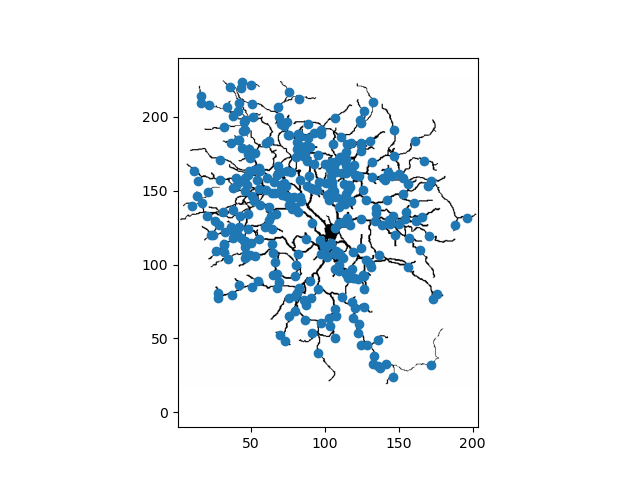

In [30]:
ffff, aaaa = plt.subplots(1)
aaaa.imshow(dsgc_img, extent=dsgc_extent)
aaaa.scatter(syn_locs[:, 0], syn_locs[:, 1])
aaaa.set_ylim(-10, 240)

In [31]:

syn_locs.shape

(341, 3)

# 